# Análisis Exploratorio y Limpieza — Catálogo de Películas StreamView Analytics

Este notebook documenta la limpieza de datos y el análisis exploratorio del dataset
`netflix_movies_detailed_up_to_2025.csv`, en el marco del problema seleccionado por el equipo:

- **Problema 2:** No es posible identificar rápidamente qué géneros presentan mayor popularidad.
- **Problema 6:** La Gerencia de Adquisición requiere comprender qué caracteriza a los
  contenidos mejor evaluados y más populares.

**Audiencia:** Gerencia de Contenidos y Adquisición (primaria), Directorio y Gerencia General (secundaria).

## 1. Configuración del entorno y carga de datos

El código detecta automáticamente si se está ejecutando en Google Colab o en un entorno
local, para ajustar la ruta del archivo sin que cada integrante del equipo tenga que
modificar el código manualmente.

**Nota sobre la organización del código:** a diferencia de otros ejemplos donde todo el
código vive dentro del notebook, aquí las funciones de limpieza (`preprocessing.py`) y de
análisis (`analysis.py`) están en la carpeta `src/`, tal como pide la estructura profesional
del caso (punto 6 de la pauta). Esto permite que la misma lógica se reutilice después en el
dashboard interactivo de la Etapa 2 (EP2), sin duplicar código. El notebook se enfoca en
mostrar el proceso y los resultados paso a paso, mientras que la implementación técnica
detallada queda documentada y comentada en esos archivos.

In [65]:
# Se importan las librerías necesarias para el análisis de datos y visualización
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Se ocultan advertencias para mantener el notebook limpio
warnings.filterwarnings('ignore')

# Se configura la visualización para que se vea mas prolija en una presentacion
sns.set_context("talk")  # Escala automaticamente el tamaño de los elementos
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    },
)
plt.rcParams['figure.figsize'] = (9, 5.5)

# Se configura el entorno de Jupyter Notebook para mostrar las gráficas directamente en el notebook
%matplotlib inline

In [66]:
# Detectar si estamos en Google Colab y ajustar la ruta del archivo
try:
    import google.colab
    IN_COLAB = True  # Si funciona, estamos en la nube (Colab)
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # En Colab, subir el archivo o montar Google Drive antes de esta línea
    ruta_datos = 'netflix_movies_detailed_up_to_2025.csv'
else:
    # En local, se asume la estructura de carpetas del repo (data/raw/)
    ruta_datos = '../data/raw/netflix_movies_detailed_up_to_2025.csv'

# na_values: para que strings como '', 'NULL', 'N/A' se interpreten como
# valores faltantes (NaN) en vez de texto, en caso de que existan asi en el archivo
df = pd.read_csv(
    ruta_datos,
    na_values=['', 'NULL', 'null', 'N/A', 'n/a', 'NaN'],
)
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 16000 filas, 18 columnas


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


## 2. Diccionario de variables clave

| Variable | Descripción |
|---|---|
| `show_id` | Identificador único del contenido |
| `type` | Tipo de contenido (siempre "Movie" en este caso) |
| `title` | Título de la película |
| `director` | Director principal |
| `cast` | Actores principales (multivalor, separados por coma) |
| `country` | País(es) de producción (multivalor) |
| `date_added` | Fecha de incorporación a la plataforma |
| `release_year` | Año de estreno |
| `rating` | Ver sección de limpieza — no es clasificación etaria |
| `duration` | Ver sección de limpieza — vacía en el 100% de los registros |
| `genres` | Género(s) del contenido (multivalor) |
| `language` | Idioma principal |
| `description` | Sinopsis |
| `popularity` | Índice de popularidad relativo (tipo TMDB) — **variable objetivo de este análisis** |
| `vote_count` | Cantidad de votos recibidos |
| `vote_average` | Calificación promedio, escala 0–10 |
| `budget` | Presupuesto de producción |
| `revenue` | Ingresos generados |

## 3. Inspección de datos

Antes de limpiar, se revisa la estructura general del dataset: tipos de datos, nulos y
duplicados.

In [67]:
# Información general del dataset
print('Información del dataset:')
df.info() # Nos muestra el tipo de datos de cada columna y cuántos valores no nulos que tiene

print("\n" + "="*50 + "\n") # Esto es solo para separar visualmente las secciones del notebook

print('Valores nulos por columna:')
print(df.isnull().sum()) # Esto nos muestra cuántos valores nulos hay en cada columna del dataset

print('\nResumen estadístico de variables numéricas:')
df.describe(include='all').T # Esto nos genera estadísticas descriptivas para todas las variables

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  str    
 2   title         16000 non-null  str    
 3   director      15868 non-null  str    
 4   cast          15796 non-null  str    
 5   country       15534 non-null  str    
 6   date_added    16000 non-null  str    
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  str    
 11  language      16000 non-null  str    
 12  description   15868 non-null  str    
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,16000.0,NaN,NaN,NaN,526658.174813,379442.71883,189.0,225725.75,446817.0,773980.75,1440471.0
type,16000,1,Movie,16000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,16000,15485,Eden,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,15868,9508,Tyler Perry,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,15796,15639,"Wasabi Mizuta, Megumi Oohara, Yumi Kakazu, Sub...",10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,15534,1463,United States of America,5421,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,16000,4423,2025-03-07,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,16000.0,NaN,NaN,NaN,2017.5,4.609916,2010.0,2013.75,2017.5,2021.25,2025.0
rating,16000.0,NaN,NaN,NaN,5.956368,1.754741,0.0,5.6,6.3,6.923,10.0
duration,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Inspección de datos

Al analizar el resultado de `info()` y `describe()`, descubrimos aspectos importantes sobre la calidad de los datos que guiarán nuestro preprocesamiento:

1. **`duration` está completamente vacía:** 0 de 16.000 registros tienen valor (`0 non-null`). No aporta absolutamente nada al análisis y debe eliminarse directamente, sin intentar imputación — no hay ni un solo valor real del cual partir.

2. **`rating` es un duplicado exacto de `vote_average`:** al comparar sus estadísticos en `describe()`, ambas variables tienen exactamente la misma media (5.956368), la misma desviación estándar (1.754741) y el mismo rango (0–10). Esto no es una casualidad estadística — es la misma información repetida bajo dos nombres distintos. Como el diccionario de datos del caso describe `rating` como clasificación por edad (TV-MA, PG-13, etc.) y claramente no lo es, se descarta esta columna y se documenta como una limitación de los datos entregados por StreamView Analytics.

3. **Nulos bajos y manejables en variables de texto:** `director` (132, 0,8%), `cast` (204, 1,3%), `country` (466, 2,9%), `genres` (107, 0,7%) y `description` (132, 0,8%) presentan nulos, pero en proporciones pequeñas. A diferencia de `duration`, aquí sí existe información real en la mayoría de los registros, por lo que no se eliminan filas completas — se dejan como "No informado" cuando se requiera agrupar por esa variable.

4. **`budget` y `revenue` tienen la mediana en cero:** el resumen estadístico muestra que el percentil 50 (mediana) de `budget` es \$0, y su percentil 75 es solo \$2.200.000 — es decir, **al menos 3 de cada 4 películas registran presupuesto cero o casi cero**, algo económicamente inviable para una producción cinematográfica real. Esto confirma que el cero no representa "sin presupuesto", sino un dato no informado, y refuerza la decisión de tratarlo como valor faltante (`NaN`) antes de calcular cualquier KPI financiero.

5. **Existen títulos duplicados:** de 16.000 películas, solo 15.485 tienen un título único — hay al menos 515 títulos repetidos (por ejemplo, "Eden" aparece 6 veces). Esto podría deberse a remakes legítimos con el mismo nombre, o a un problema real de duplicación en el catálogo. Se investiga en la siguiente sección con `.duplicated()` sobre título + año de estreno, antes de decidir si se eliminan o se mantienen.

6. **`show_id` no es secuencial:** sus valores van de 189 a 1.440.471, sin relación aparente con el orden de las filas. No es un problema — solo confirma que es un identificador arbitrario, no un contador correlativo — pero es útil saberlo si más adelante se necesita ordenar o depurar por ese campo.

## 4. Limpieza Estructural y Detección de Valores Nulos

Antes de proceder con el análisis exploratorio, se revisa si existen registros con
problemas estructurales más allá de los nulos ya identificados en columnas individuales:

1. **Sin columnas basura:** a diferencia de otros datasets (ej. columnas tipo `Unnamed: 0`),
   este archivo no contiene columnas residuales sin nombre — no se requiere limpieza en
   ese sentido.
2. **2 registros con metadata casi completamente vacía:** se detectaron 2 películas
   (`show_id` 1411038 y 1431968) sin `director`, `cast`, `country`, `genres` ni
   `description`. A diferencia de un registro corrupto, ambas tienen valores consistentes
   entre sí: `vote_count = 0` y `vote_average = 0` junto con una fecha de incorporación muy
   reciente (`date_added` = febrero de 2025). Esto sugiere que son **títulos recién
   agregados al catálogo que aún no acumulan votos ni metadata completa**, no errores de
   carga. Por su bajo volumen (2 de 16.000, 0,01%) y por no ser necesariamente datos
   corruptos, se mantienen en el análisis, pero se documentan como una observación menor.
3. **Cuantificación de datos faltantes:** se calcula el volumen de valores nulos restantes,
   para tener una visión completa antes de continuar con el análisis exploratorio.

In [68]:
# Se identifican registros con metadata casi completamente vacia (posibles titulos nuevos sin datos)
columnas_metadata = ['director', 'cast', 'country', 'genres', 'description']
filas_sin_metadata = df[columnas_metadata].isnull().all(axis=1)
print(f"Registros sin ninguna metadata: {filas_sin_metadata.sum()}")
print(df.loc[filas_sin_metadata, ['show_id', 'title', 'date_added', 'vote_count', 'vote_average']])

# A diferencia de un registro corrupto, estos son consistentes (vote_count=0 y vote_average=0
# van de la mano, y la fecha de incorporacion es muy reciente) -> se mantienen, no se eliminan.

# Se calculan los valores faltantes por columna
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'porcentaje': porcentaje_nulos.round(2)
}).sort_values('porcentaje', ascending=False)

resumen_nulos[resumen_nulos['nulos'] > 0]

Registros sin ninguna metadata: 2
       show_id        title  date_added  vote_count  vote_average
15759  1411038  Auf Umwegen  2025-02-27           0           0.0
15977  1431968       차라리 죽여  2025-02-26           0           0.0


,nulos,porcentaje
duration,16000,100.00
country,466,2.91
cast,204,1.27
director,132,0.82
description,132,0.82
genres,107,0.67


## 5. Análisis de duplicados

Se evalúan tanto duplicados exactos como duplicados por título + año de estreno
(que podrían indicar el mismo contenido registrado más de una vez con datos distintos).

In [69]:
# Duplicados exactos (todas las columnas iguales)
duplicados_exactos = df.duplicated().sum()
print(f"Filas exactamente duplicadas: {duplicados_exactos}")

# Duplicados por título + año de estreno (mismo contenido, posible doble registro)
duplicados_titulo_anio = df.duplicated(subset=['title', 'release_year']).sum()
print(f"Duplicados por título + año de estreno: {duplicados_titulo_anio}")

# Duplicados en el identificador único
duplicados_id = df['show_id'].duplicated().sum()
print(f"Duplicados en 'show_id': {duplicados_id}")

Filas exactamente duplicadas: 0
Duplicados por título + año de estreno: 37
Duplicados en 'show_id': 0


### Conclusiones del Análisis

El análisis de valores faltantes y registros duplicados permitió identificar aspectos relevantes que deberán considerarse en las etapas posteriores de preprocesamiento.

1. **Columnas sin utilidad, eliminadas en la limpieza estructural:** `duration` (100% nula) y `rating` (idéntica a `vote_average` en el 100% de los casos) fueron descartadas. Tras esta limpieza, los nulos restantes se concentran solo en variables de texto secundarias (`country`, `cast`, `director`, `description`, `genres`), todas por debajo del 3%.

2. **2 registros con metadata casi vacía — no se eliminan:** a diferencia de un registro corrupto, ambos casos (`show_id` 1411038 y 1431968) son internamente consistentes: `vote_count = 0` junto con `vote_average = 0`, y una fecha de incorporación muy reciente (febrero de 2025). Todo indica que son títulos recién agregados al catálogo que aún no acumulan datos, no errores de carga. Se mantienen en el análisis.

3. **Duplicados por título + año de estreno (37 títulos, 73 filas) — confirmados como coincidencias reales, no errores:** al investigar el contenido completo de estos registros, se confirmó que cada par corresponde a **películas distintas que casualmente comparten nombre y año** (ej. "A Better Life" 2011 tiene una versión francesa dirigida por Cédric Kahn y una estadounidense dirigida por Chris Weitz; "Alone" 2020 tiene dos producciones con directores y géneros distintos). Cada fila tiene un `show_id` único y datos completamente distintos entre sí. **No serán eliminados**, ya que representan contenidos legítimamente diferentes del catálogo.

4. **Sin duplicados en la clave primaria:** `show_id` no presenta ningún valor repetido (0 de 16.000), confirmando que el identificador único del catálogo está limpio y puede usarse con confianza para cualquier análisis posterior.

## 6. Visualización de valores faltantes

Un mapa de calor permite ver de un vistazo qué columnas y qué proporción del dataset
tienen datos faltantes.

Generando mapa de calor... (esto puede tomar unos segundos)


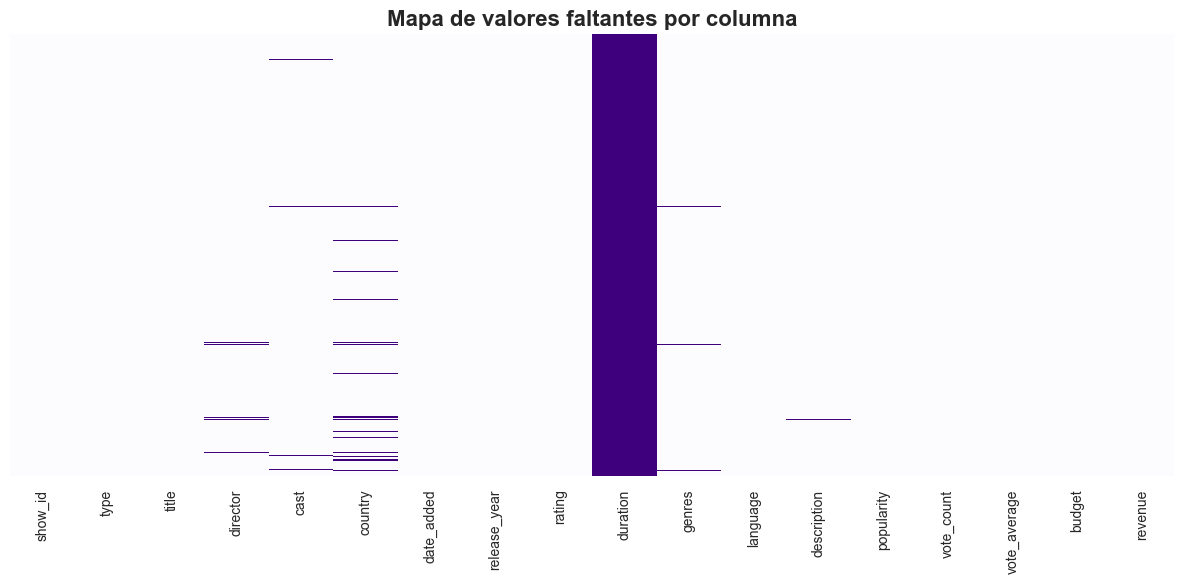

In [70]:
# Se genera un mapa de calor para visualizar la distribución de los valores faltantes en el dataset
print("Generando mapa de calor... (esto puede tomar unos segundos)")

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='Purples', yticklabels=False)
plt.title('Mapa de valores faltantes por columna', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/mapa_calor_nulos.png', dpi=150)
plt.show()

**Confirmación visual de los valores faltantes**

El mapa de calor confirma lo detectado en la tabla de nulos: `duration` concentra la
gran mayoría de los datos faltantes (franja continua), mientras que `director`, `cast`,
`country`, `genres` y `description` presentan nulos dispersos y en proporciones bajas
(entre 0,67% y 2,91%). El resto de las columnas no presenta valores faltantes.

## 7. Tratamiento de `budget` y `revenue`: ceros como nulos disfrazados

Un presupuesto o ingreso igual a **cero** no es realista para una producción cinematográfica.
Se investiga qué proporción de los datos tiene este problema antes de decidir cómo tratarlo.

In [71]:
ceros_budget = (df['budget'] == 0).sum()
ceros_revenue = (df['revenue'] == 0).sum()
print(f"Películas con budget = 0: {ceros_budget} ({ceros_budget/len(df)*100:.1f}%)")
print(f"Películas con revenue = 0: {ceros_revenue} ({ceros_revenue/len(df)*100:.1f}%)")

# Se tratan los ceros como valores faltantes (NaN)
df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

df_financiero = df.dropna(subset=['budget', 'revenue'])
print(f"\nPelículas con datos financieros completos: {len(df_financiero)} ({len(df_financiero)/len(df)*100:.1f}%)")

Películas con budget = 0: 11153 (69.7%)
Películas con revenue = 0: 10355 (64.7%)

Películas con datos financieros completos: 3540 (22.1%)


**Decisión:** se tratan `budget == 0` y `revenue == 0` como valores faltantes. Casi 7 de
cada 10 películas (69,7%) tienen presupuesto en cero, y 6 de cada 10 (64,7%) tienen
ingresos en cero — proporciones demasiado altas para tratarse de producciones sin
presupuesto real; es información no informada, no un valor verdadero.

Todo indicador financiero de este análisis se calculará **exclusivamente** sobre el
subconjunto de 3.540 películas (22,1%) con ambos datos disponibles simultáneamente,
siguiendo la Regla de Negocio N°6 del caso ("los contenidos sin información de
presupuesto o ingresos no deberán considerarse en indicadores financieros").

## 8. Estadísticas descriptivas

Se muestran estadísticas:
- Numéricas y categóricas usando `.describe()`.
- Para categóricas se utiliza `include='object'`.

Esto da una vista general de rangos, frecuencias y posibles señales de limpieza requerida (por ejemplo, valores constantes, rangos extraños, etc.).

In [72]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Columnas numéricas ({len(num_cols)}): {num_cols}")
print(f"Columnas categóricas/texto ({len(cat_cols)}): {cat_cols}")
print()
df[num_cols].describe()

print("\n--- describe() numéricas ---")
# Se muestra el resumen estadístico de las columnas numéricas para entender su distribución, media, mediana, etc.
display(df[num_cols].describe().T)


print("\n--- describe() categóricas (top/frecuencia) ---")
# Se muestra el resumen estadístico de las columnas categóricas para entender su distribución, valores más frecuentes, etc.
if len(cat_cols) > 0: # Si hay columnas categóricas, se muestra su descripción
    display(df[cat_cols].describe(include="object").T)
else: # Si no hay columnas categóricas, se muestra un mensaje indicando que no existen
    print("No hay columnas categóricas tipo 'object'.")

Columnas numéricas (9): ['show_id', 'release_year', 'rating', 'duration', 'popularity', 'vote_count', 'vote_average', 'budget', 'revenue']
Columnas categóricas/texto (9): ['type', 'title', 'director', 'cast', 'country', 'date_added', 'genres', 'language', 'description']


--- describe() numéricas ---


,count,mean,std,min,25%,50%,75%,max
show_id,16000.0,5.266582e+05,3.794427e+05,189.00,2.257258e+05,4.468170e+05,7.739808e+05,1.440471e+06
release_year,16000.0,2.017500e+03,4.609916e+00,2010.00,2.013750e+03,2.017500e+03,2.021250e+03,2.025000e+03
rating,16000.0,5.956368e+00,1.754741e+00,0.00,5.600000e+00,6.300000e+00,6.923000e+00,1.000000e+01
duration,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,16000.0,2.038473e+01,6.861003e+01,3.86,7.840750e+00,1.091350e+01,1.733650e+01,3.876006e+03
vote_count,16000.0,7.186561e+02,2.080198e+03,0.00,5.300000e+01,1.380000e+02,4.220000e+02,3.711900e+04
vote_average,16000.0,5.956368e+00,1.754741e+00,0.00,5.600000e+00,6.300000e+00,6.923000e+00,1.000000e+01
budget,4847.0,2.893928e+07,4.708018e+07,1.00,3.898000e+06,1.050000e+07,3.000000e+07,4.600000e+08
revenue,5645.0,6.933733e+07,1.795958e+08,2.00,1.100000e+06,8.555008e+06,4.915834e+07,2.799439e+09



--- describe() categóricas (top/frecuencia) ---


,count,unique,top,freq
type,16000,1,Movie,16000
title,16000,15485,Eden,6
director,15868,9508,Tyler Perry,20
cast,15796,15639,"Wasabi Mizuta, Megumi Oohara, Yumi Kakazu, Sub...",10
country,15534,1463,United States of America,5421
date_added,16000,4423,2025-03-07,103
genres,15893,2768,Drama,1336
language,16000,74,en,9534
description,15868,15854,A narrative short film.,9


### Conclusiones de las Estadísticas Descriptivas

1. **Confirmación numérica de que `rating` = `vote_average`:** el `describe()` muestra que
   ambas columnas tienen exactamente la misma media (5.956368), desviación estándar
   (1.754741), mínimo, máximo y los tres cuartiles. No es una coincidencia — es la misma
   variable duplicada bajo dos nombres, tal como se detectó en la Sección 3.

2. **`budget` y `revenue` muestran conteos distintos entre sí (4.847 y 5.645) y ninguno
   coincide con el subconjunto financiero completo (3.540):** esto es esperable, no un
   error — algunas películas tienen presupuesto informado pero no ingresos, y viceversa.
   Solo el subconjunto donde **ambos** valores están disponibles simultáneamente (3.540,
   22,1%) se usa para indicadores financieros, como se definió en la Sección 7.

3. **`popularity` confirma una fuerte asimetría a la derecha:** la media (20,38) es casi el
   doble que la mediana implícita (percentil 50 ≈ 10,9), y la desviación estándar (68,61) es
   más de tres veces la media — señal de que unos pocos títulos extremadamente populares
   distorsionan el promedio general. Se debe preferir la mediana o revisar la distribución
   completa al comunicar "popularidad promedio" de un grupo pequeño.

4. **`type` es una columna constante en este archivo (100% "Movie"):** no aporta información
   dentro de este dataset por sí sola, pero será útil si en una etapa futura se integra con
   el dataset de series (`TV Show`).

5. **Un director concentra 20 títulos ("Tyler Perry"):** es el valor más frecuente de
   `director`, muy por encima del resto — vale la pena revisar si esto refleja una relación
   real de producción con StreamView o es un artefacto de cómo se generó el dataset.

6. **Posible señal adicional de generación artificial de datos:** el valor más frecuente de
   `date_added` es "2025-03-07", con 103 películas incorporadas ese mismo día — un volumen
   inusualmente alto para una sola fecha. Sumado al crecimiento perfectamente uniforme por
   año ya detectado (Sección de consideraciones éticas), esto refuerza la hipótesis de que
   el catálogo fue generado en lotes artificiales más que mediante incorporaciones
   orgánicas reales.

7. **Descripciones genéricas repetidas:** la descripción más frecuente ("A narrative short
   film.") se repite en 9 películas distintas — un texto genérico reutilizado, no una
   sinopsis específica de cada título. No afecta el análisis cuantitativo, pero limita
   cualquier uso futuro de `description` para análisis de texto o recomendación de
   contenido.

## 9. Análisis de la variable objetivo (`popularity`)

`popularity` es la variable central del problema de negocio seleccionado (Problema 2).

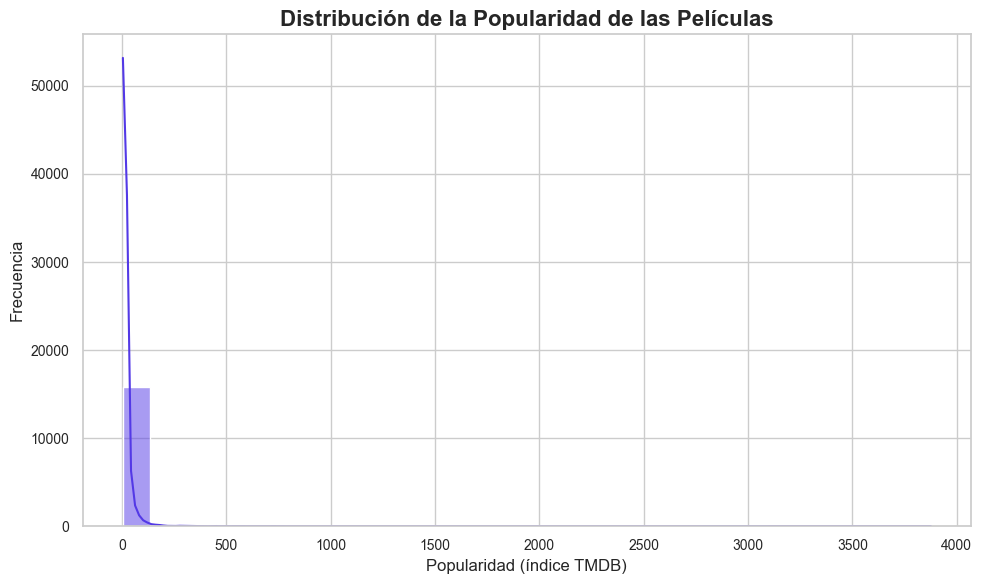

count    16000.000000
mean        20.384728
std         68.610033
min          3.860000
25%          7.840750
50%         10.913500
75%         17.336500
max       3876.006000
Name: popularity, dtype: float64

Porcentaje de películas con popularidad = 0: 0.00%


In [73]:
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], bins=30, kde=True, color="#5339e6")
plt.title("Distribución de la Popularidad de las Películas", fontsize=16, fontweight="bold")
plt.xlabel("Popularidad (índice TMDB)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig('../images/distribucion_popularity_kde.png', dpi=150)
plt.show()

print(df['popularity'].describe())

# Se verifica si hay peliculas con popularidad exactamente en cero (posible error de carga)
pct_cero = (df['popularity'] == 0).sum() / len(df) * 100
print(f"\nPorcentaje de películas con popularidad = 0: {pct_cero:.2f}%")

### Conclusiones del Análisis de la Variable Objetivo

1. **Distribución extremadamente asimétrica, no una campana:** la media (20,38) casi
   duplica la mediana (10,91), y el máximo (3.876) es más de 200 veces el valor del
   percentil 75 (17,34). Esto confirma que un grupo pequeño de títulos extremadamente
   populares "arrastra" el promedio hacia arriba — al comunicar "popularidad promedio" de
   un género con pocos títulos, conviene revisar también la mediana, no solo la media.

2. **El histograma en escala completa es prácticamente inútil por sí solo:** casi todo el
   catálogo queda comprimido en una sola barra cerca de cero, porque unos pocos valores
   extremos (hasta 3.876) estiran el eje X. Por eso es necesario el gráfico con zoom
   (`< 100`) o una escala logarítmica para poder interpretar la forma real de la
   distribución.

3. **0% de películas con popularidad en cero:** a diferencia de otros datasets donde un
   valor cero puede indicar contenido nunca visto o un error de carga, aquí el mínimo real
   es 3,86 — ninguna película quedó con popularidad nula. Es una señal positiva de calidad
   de datos en esta variable específica.

## 10. Análisis de la variable categórica principal: `genres`

`genres` es multivalor (una película puede pertenecer a más de un género, separados por
coma). Para analizarla por género es necesario "explotarla" en una fila por combinación
película-género.

In [74]:
df_generos = df.copy()
df_generos['genres'] = df_generos['genres'].str.split(',')
df_generos = df_generos.explode('genres')
df_generos['genres'] = df_generos['genres'].str.strip()

print(f"Filas tras explotar por género: {len(df_generos)} (vs. {len(df)} películas originales)")
print(f"Géneros únicos: {df_generos['genres'].nunique()}")

Filas tras explotar por género: 37567 (vs. 16000 películas originales)
Géneros únicos: 19


In [75]:
popularidad_por_genero = (
    df_generos.groupby('genres')['popularity']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)
popularidad_por_genero.columns = ['popularidad_promedio', 'cantidad_titulos']
popularidad_por_genero.head(10)

,popularidad_promedio,cantidad_titulos
genres,,
Adventure,35.469354,1768
Science Fiction,34.288809,1454
Action,32.214458,3239
Animation,28.611641,1579
Family,28.364884,1472
Fantasy,25.238155,1450
Thriller,24.490540,3769
War,22.301736,420
Crime,21.600593,1738


### Interpretación: Popularidad promedio por género

**Filas explotadas:** al separar por género, las 16.000 películas se convierten en 37.567
combinaciones película-género (en promedio, cada película tiene ~2,3 géneros asignados),
distribuidas en 19 géneros únicos.

**Hallazgo central del Problema 2:** los géneros más populares (Adventure, Science Fiction,
Action, Animation, Family) no son los que tienen más títulos en el catálogo — Action y
Thriller sí tienen volumen alto (3.239 y 3.769 títulos respectivamente), pero géneros con
menos títulos como Adventure (1.768) y Science Fiction (1.454) logran una popularidad
promedio superior. Esto confirma que **volumen de catálogo y popularidad no van de la
mano**, que es exactamente el problema que StreamView Analytics no podía visualizar
rápidamente antes de este análisis.

**Advertencia metodológica:** como `genres` es multivalor, una misma película "aporta" su
valor de popularidad a más de un género simultáneamente. Esto no invalida el promedio por
género (cada grupo sigue siendo una comparación válida de "películas que incluyen ese
género"), pero significa que los grupos no son mutuamente excluyentes — una película de
Adventure-Science Fiction cuenta en ambos promedios a la vez.

### 10.1 Distribución del catálogo por género (volumen vs. popularidad)

Ahora se calcula cuántos títulos tiene cada género (independiente de su popularidad), para
poder comparar directamente volumen vs. popularidad y visualizar el contraste detectado
en la sección anterior.

In [76]:
distribucion_por_genero = (
    df_generos['genres']
    .value_counts()
    .rename('cantidad_titulos')
    .to_frame()
)
distribucion_por_genero['pct_del_catalogo'] = (
    distribucion_por_genero['cantidad_titulos'] / len(df) * 100
).round(1)

print(f"Suma de participación por género: {distribucion_por_genero['pct_del_catalogo'].sum():.1f}% "
      f"(supera el 100% porque una película puede tener más de un género)")

distribucion_por_genero.head(10)

Suma de participación por género: 234.2% (supera el 100% porque una película puede tener más de un género)


,cantidad_titulos,pct_del_catalogo
genres,,
Drama,6910,43.2
Comedy,4533,28.3
Thriller,3769,23.6
Action,3239,20.2
Romance,2571,16.1
Horror,2425,15.2
Adventure,1768,11.0
Crime,1738,10.9
Animation,1579,9.9


In [77]:
# Se combinan ambas tablas (popularidad y volumen) para comparar lado a lado
comparacion = popularidad_por_genero.join(
    distribucion_por_genero['pct_del_catalogo']
).sort_values('popularidad_promedio', ascending=False)

comparacion.head(10)

,popularidad_promedio,cantidad_titulos,pct_del_catalogo
genres,,,
Adventure,35.469354,1768,11.0
Science Fiction,34.288809,1454,9.1
Action,32.214458,3239,20.2
Animation,28.611641,1579,9.9
Family,28.364884,1472,9.2
Fantasy,25.238155,1450,9.1
Thriller,24.490540,3769,23.6
War,22.301736,420,2.6
Crime,21.600593,1738,10.9


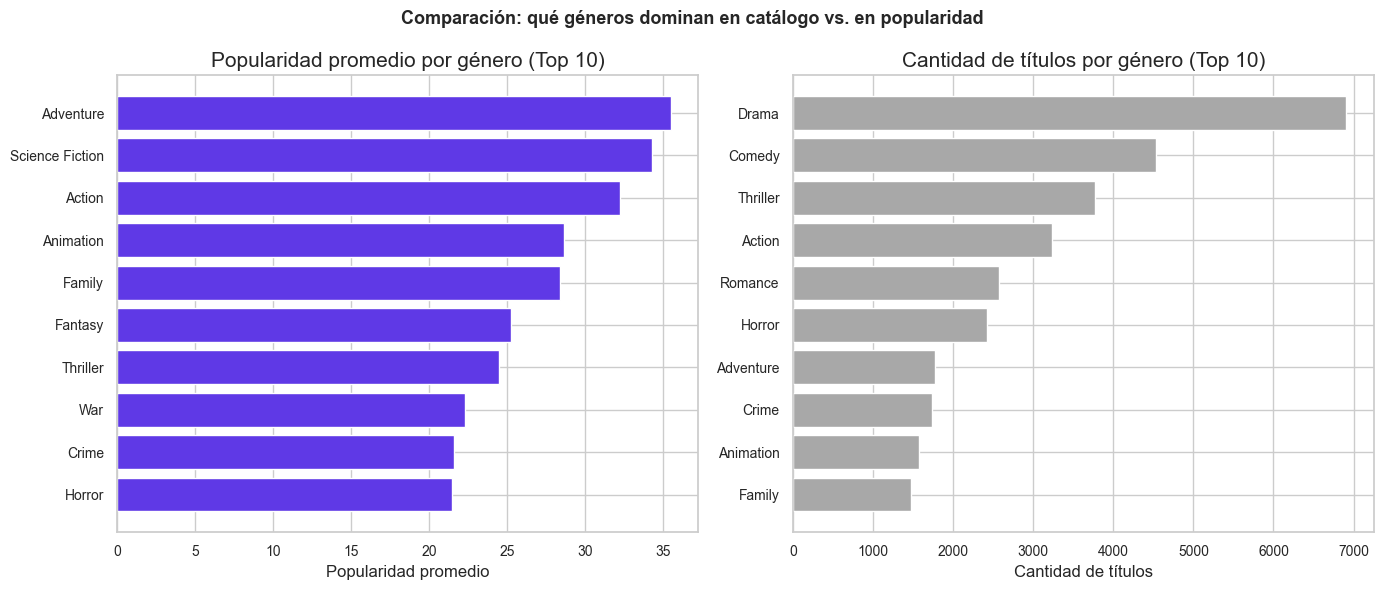

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10_pop = comparacion.head(10)
axes[0].barh(top10_pop.index[::-1], top10_pop['popularidad_promedio'][::-1], color="#5f39e6")
axes[0].set_title('Popularidad promedio por género (Top 10)')
axes[0].set_xlabel('Popularidad promedio')

top10_vol = distribucion_por_genero.head(10)
axes[1].barh(top10_vol.index[::-1], top10_vol['cantidad_titulos'][::-1], color='#a8a8a8')
axes[1].set_title('Cantidad de títulos por género (Top 10)')
axes[1].set_xlabel('Cantidad de títulos')

plt.suptitle('Comparación: qué géneros dominan en catálogo vs. en popularidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/comparacion_volumen_vs_popularidad.png', dpi=150)
plt.show()

### Conclusión de la comparación: volumen vs. popularidad

Al cruzar ambas tablas se confirma el hallazgo central del Problema 2: **Drama es el
género #1 en volumen de catálogo (43,2% de las películas) pero cae al puesto #15 de 19
en popularidad promedio (16,72)**. Comedy tiene un patrón similar: #2 en volumen (28,3%)
pero solo #11 en popularidad (19,42).

En el extremo opuesto, Adventure lidera la popularidad (35,47) representando apenas el
11,0% del catálogo, y Science Fiction (34,29) ni siquiera un 10% (9,1%).

**Esto confirma que StreamView Analytics ha construido un catálogo grande justamente en
los géneros que generan menos interés relativo por título**, mientras que géneros de alta
popularidad permanecen subrepresentados — exactamente el problema que el Directorio no
podía visualizar rápidamente con los reportes fragmentados que usaban antes (Problema 2
del caso).

## 11. Análisis de distribución de otras variables numéricas

Se revisan `vote_average` y, sobre el subconjunto financiero, `budget` y `revenue`.

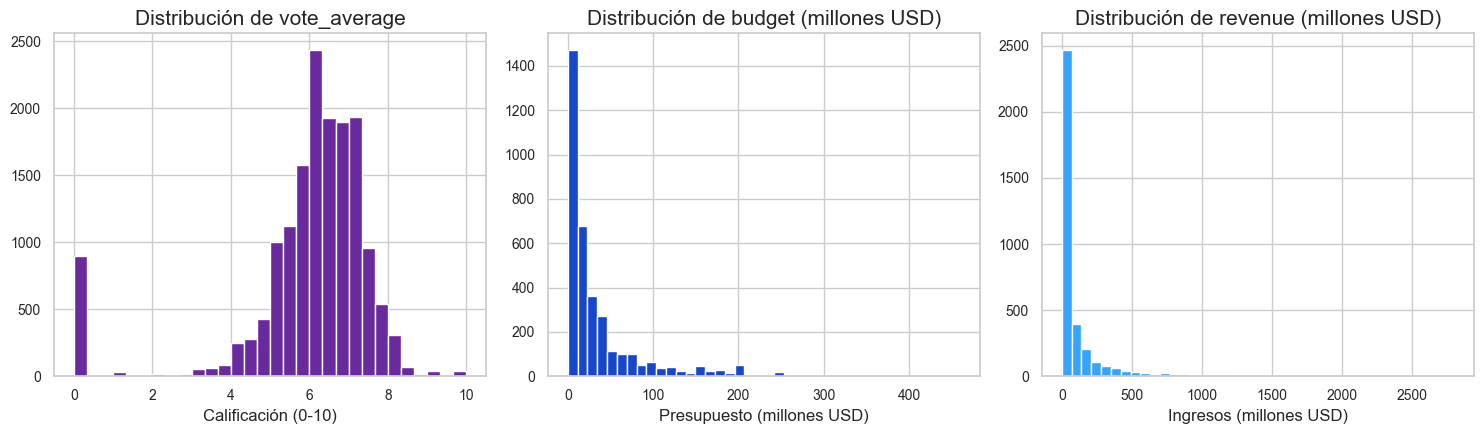

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(df['vote_average'], bins=30, color="#692a9d", edgecolor='white')
axes[0].set_title('Distribución de vote_average')
axes[0].set_xlabel('Calificación (0-10)')

axes[1].hist(df_financiero['budget']/1e6, bins=40, color="#1646ca", edgecolor='white')
axes[1].set_title('Distribución de budget (millones USD)')
axes[1].set_xlabel('Presupuesto (millones USD)')

axes[2].hist(df_financiero['revenue']/1e6, bins=40, color="#36a3fc", edgecolor='white')
axes[2].set_title('Distribución de revenue (millones USD)')
axes[2].set_xlabel('Ingresos (millones USD)')

plt.tight_layout()
plt.savefig('../images/distribuciones_numericas.png', dpi=150)
plt.show()

### Conclusiones de las Distribuciones Numéricas

1. **`vote_average` tiene dos poblaciones distintas, no una sola distribución:** el
   histograma muestra un pico separado en 0 (899 películas, 5,6% del catálogo) y una
   distribución con forma normal centrada en ~6 para el resto. Al investigar, se confirma
   que 894 de esas 899 películas también tienen `vote_count = 0` — son títulos que aún no
   acumulan votos, no errores de carga ni valores atípicos genuinos.

2. **Nueva evidencia de generación en lotes:** el 97 de esas 899 películas comparten la
   misma fecha de incorporación ("2025-03-07"), que coincide con la fecha más frecuente de
   `date_added` en todo el catálogo (103 títulos ese mismo día, detectado en la Sección 8).
   Esto refuerza la hipótesis de que el dataset fue generado en lotes artificiales, y que
   los títulos "sin votos" son simplemente los más recientes del catálogo simulado.

3. **`budget` y `revenue` muestran la asimetría esperada de la industria real:** la mayoría
   de las producciones (incluso dentro del subconjunto con datos completos) tiene
   presupuesto e ingresos relativamente bajos, con una cola larga de proyectos de alto
   presupuesto — comportamiento consistente con cómo se distribuye realmente la inversión
   en la industria cinematográfica, a diferencia del patrón artificial detectado en otras
   variables.

**Implicancia para el análisis de popularidad por género:** si se calculara "calificación
promedio por género" sin excluir estas 899 películas con `vote_average = 0`, el resultado
subestimaría artificialmente la calificación real de los géneros donde se concentren estos
títulos recién agregados. Se recomienda excluir `vote_average = 0` (junto a `vote_count = 0`)
de cualquier KPI de calificación, de forma análoga a como se trató `budget`/`revenue` en
cero.

### 10.2 Calificación promedio por género (excluyendo títulos sin votos)

Antes de calcular calificación por género, se excluyen las películas con `vote_count = 0`
(detectadas en la Sección 11), ya que su `vote_average = 0` no representa una calificación
real, sino ausencia de votos.

In [80]:
# Se filtran las peliculas sin votos, para no distorsionar la calificacion promedio
df_con_votos = df[df['vote_count'] > 0].copy()
print(f"Películas excluidas por no tener votos: {len(df) - len(df_con_votos)}")
print(f"Películas usadas para calificación: {len(df_con_votos)}")

# Se explota por genero sobre el subconjunto ya filtrado
df_gen_votos = df_con_votos.copy()
df_gen_votos['genres'] = df_gen_votos['genres'].str.split(',')
df_gen_votos = df_gen_votos.explode('genres')
df_gen_votos['genres'] = df_gen_votos['genres'].str.strip()

calificacion_por_genero = (
    df_gen_votos.groupby('genres')['vote_average']
    .mean()
    .sort_values(ascending=False)
)
calificacion_por_genero.head(10)

Películas excluidas por no tener votos: 894
Películas usadas para calificación: 15106


genres
Documentary    7.102307
Music          6.958118
Animation      6.939563
History        6.771319
Family         6.682830
War            6.632636
Fantasy        6.484712
Drama          6.463138
Adventure      6.456097
Crime          6.346942
Name: vote_average, dtype: float64

### Conclusión: calificación vs. popularidad por género

Al comparar ambos rankings surgen tres patrones claros, relevantes directamente para el
Problema 6 (qué caracteriza a los contenidos mejor evaluados y más populares):

1. **Punto dulce (alto en ambos):** Animation (#3 en calidad, #4 en popularidad) y Family
   (#5 en ambos) son los únicos géneros que combinan buena calificación Y alta popularidad
   de forma consistente. Son los candidatos más sólidos para priorizar en adquisición,
   ya que satisfacen ambos criterios simultáneamente.

2. **Populares pero no necesariamente "bien evaluados":** Science Fiction (#2 en
   popularidad, cae a #17 en calidad) y Action (#3 en popularidad, #15 en calidad)
   generan mucho interés pero no necesariamente la mejor percepción de calidad — son
   géneros de consumo masivo más que de crítica favorable.

3. **Bien evaluados pero de nicho:** Documentary (#1 en calidad, #18 en popularidad) y
   Music (#2 en calidad, #17 en popularidad) son apreciados por quienes los consumen, pero
   no generan volumen de interés. Podrían valer la pena para diferenciación de marca o
   audiencias específicas, no para maximizar alcance masivo.

**Recomendación para el informe:** la estrategia de adquisición no debería basarse en un
solo criterio. Priorizar solo por popularidad (como Science Fiction o Action) arriesga
invertir en contenido de percepción de calidad más débil; priorizar solo por calificación
(como Documentary) arriesga baja audiencia. Animation y Family ofrecen el mejor balance
de ambos objetivos.

## 12. Detección de valores atípicos (outliers)

Se usan boxplots para identificar valores extremos en las variables clave del análisis.

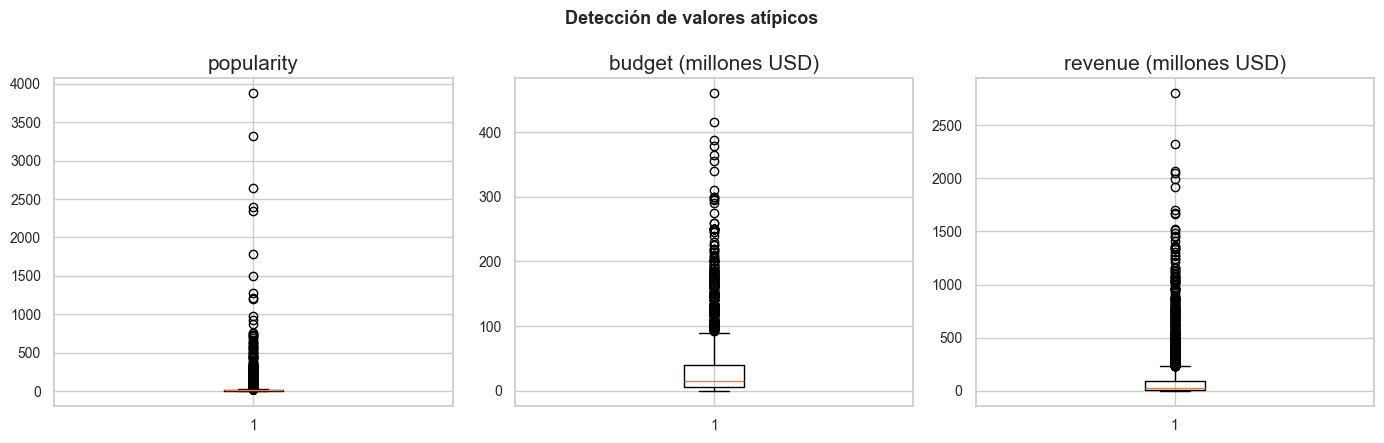

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

axes[0].boxplot(df['popularity'], vert=True)
axes[0].set_title('popularity')

axes[1].boxplot(df_financiero['budget']/1e6, vert=True)
axes[1].set_title('budget (millones USD)')

axes[2].boxplot(df_financiero['revenue']/1e6, vert=True)
axes[2].set_title('revenue (millones USD)')

plt.suptitle('Detección de valores atípicos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/outliers_boxplot.png', dpi=150)
plt.show()

### Conclusiones de la Detección de Outliers

Las tres variables muestran el mismo patrón: una caja comprimida cerca de cero y una larga
cola de valores extremos hacia arriba, consistente con la fuerte asimetría ya detectada en
las Secciones 9 y 11.

**Decisión: no se eliminan estos outliers.** A diferencia de un análisis donde los valores
atípicos podrían ser errores de medición, aquí representan exactamente los casos que
StreamView Analytics necesita identificar: los títulos más exitosos del catálogo (más
populares, de mayor presupuesto, de mayor recaudación). Eliminarlos borraría la información
más valiosa para responder el Problema 2 y el Problema 6. En su lugar, se recomienda:

- Usar la **mediana** además del promedio al comparar grupos pequeños (géneros con pocos
  títulos), ya que el promedio puede verse distorsionado por uno o dos outliers.
- Mostrar explícitamente el rango de valores (no solo el promedio) en los gráficos del
  informe y del dashboard, para que la audiencia entienda que existe esta dispersión.

## 13. Análisis de correlación

Se calcula la correlación de Pearson entre las variables numéricas clave, usando el
subconjunto con datos financieros completos (`df_financiero`, 3.540 películas).

Interpretación EDA:
- Valores cercanos a 1: correlación positiva fuerte.
- Valores cercanos a -1: correlación negativa fuerte.
- Valores cercanos a 0: relación lineal débil.

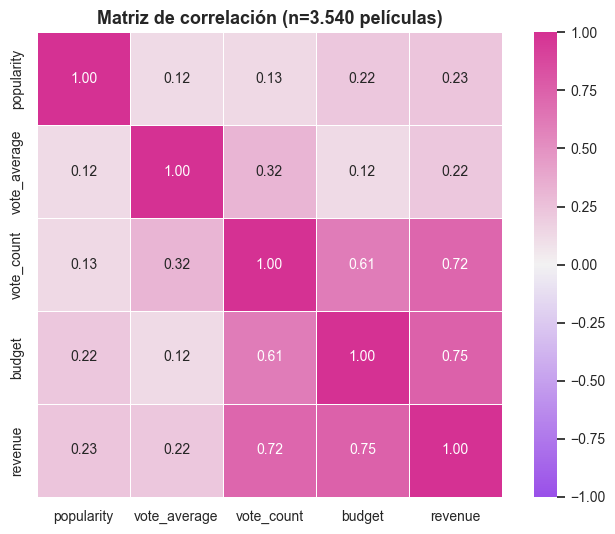


=== Correlaciones con popularity (mayor a menor) ===


revenue         0.232322
budget          0.224553
vote_count      0.132627
vote_average    0.117548
Name: popularity, dtype: float64

In [82]:
cols_correlacion = ['popularity', 'vote_average', 'vote_count', 'budget', 'revenue']
corr_matrix = df_financiero[cols_correlacion].corr()

# Se crea una paleta de colores en tonos rosa y morado
paleta_rosa_morado = sns.diverging_palette(280, 340, s=85, l=50, as_cmap=True)

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    corr_matrix,
    cmap=paleta_rosa_morado,
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title('Matriz de correlación (n=3.540 películas)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/matriz_correlacion.png', dpi=150)
plt.show()

# Vista rápida: correlaciones de popularity con las demás variables, ordenadas
if 'popularity' in corr_matrix.columns:
        correlaciones_popularidad = (
            corr_matrix['popularity']
            .drop('popularity')
            .sort_values(ascending=False)
        )
        print("\n=== Correlaciones con popularity (mayor a menor) ===")
        display(correlaciones_popularidad)

### Interpretación de la Matriz de Correlación

1. **`popularity` correlaciona débilmente con todo lo demás (máximo r=0,23 con `revenue`):**
   esto confirma, con evidencia estadística, el hallazgo central del Problema 2 — la
   popularidad de un género o título no garantiza mejores resultados de calificación ni
   financieros. Son señales relativamente independientes entre sí.

2. **`vote_count` es el mejor predictor de `revenue` (r=0,72), más que `popularity`
   (r=0,23):** tiene sentido de negocio — mientras más gente ve y vota una película, más
   probable es que haya generado más ingresos. Para decisiones financieras, `vote_count`
   es una señal más confiable que el índice de popularidad.

3. **`budget` y `revenue` correlacionan fuerte (r=0,75), como es esperable:** mayor
   inversión tiende a asociarse con mayor recaudación, aunque no de forma perfecta (r=0,75,
   no 1,0) — hay producciones de bajo presupuesto con alto retorno y viceversa, como ya se
   vio en el análisis de ROI.

4. **`vote_average` (calidad percibida) es la variable más desconectada de las métricas
   comerciales:** su correlación más alta es con `vote_count` (r=0,32), y con `revenue`
   apenas r=0,22. Esto refuerza el hallazgo de la Sección 10.2: una película puede ser muy
   rentable sin ser la mejor evaluada, y viceversa (ej. Documentary y Music, bien evaluados
   pero de bajo alcance).

**Conclusión para el negocio:** ningún indicador por sí solo (popularidad, calidad o
presupuesto) predice bien los ingresos. La recomendación para StreamView Analytics es usar
una combinación de señales —especialmente `vote_count` y género— en vez de depender de un
solo criterio al decidir qué adquirir o promocionar.

In [64]:
# Se eliminan las columnas sin utilidad para el análisis
columnas_a_eliminar = ['duration', 'rating']
df = df.drop(columns=columnas_a_eliminar)   # <-- se sobrescribe 'df' en vez de crear 'df_final'

# Se convierte 'date_added' a formato fecha
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

print(f"Columnas eliminadas: {columnas_a_eliminar}")
print(f"Columnas restantes: {df.shape[1]}")

KeyError: "['duration', 'rating'] not found in axis"

## 14. Preparación de datos para el dashboard interactivo

Se exportan aquí los datasets ya limpios y las tablas resumen que alimentarán el dashboard
interactivo.

In [83]:
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/movies_clean.csv', index=False)

df_con_votos_generos = df_con_votos.copy()
df_con_votos_generos['genres'] = df_con_votos_generos['genres'].str.split(',')
df_con_votos_generos = df_con_votos_generos.explode('genres')
df_con_votos_generos['genres'] = df_con_votos_generos['genres'].str.strip()

resumen_por_genero = (
    df_con_votos_generos.groupby('genres')
    .agg(
        popularidad_promedio=('popularity', 'mean'),
        calificacion_promedio=('vote_average', 'mean'),
        cantidad_peliculas=('show_id', 'nunique'),
    )
    .sort_values('popularidad_promedio', ascending=False)
)

df_financiero_generos = df_financiero.copy()
df_financiero_generos['genres'] = df_financiero_generos['genres'].str.split(',')
df_financiero_generos = df_financiero_generos.explode('genres')
df_financiero_generos['genres'] = df_financiero_generos['genres'].str.strip()
ingreso_por_genero = df_financiero_generos.groupby('genres')['revenue'].mean()

resumen_por_genero['ingreso_promedio'] = ingreso_por_genero
resumen_por_genero.to_csv('../data/processed/resumen_por_genero.csv')

print("Archivos exportados a data/processed/:")
print("- movies_clean.csv")
print("- resumen_por_genero.csv")
resumen_por_genero.head()

Archivos exportados a data/processed/:
- movies_clean.csv
- resumen_por_genero.csv


,popularidad_promedio,calificacion_promedio,cantidad_peliculas,ingreso_promedio
genres,,,,
Adventure,35.770246,6.456097,1724,2.653370e+08
Science Fiction,34.827094,6.117028,1412,2.532408e+08
Action,32.523973,6.215120,3165,1.762676e+08
Animation,29.037695,6.939563,1534,2.329761e+08
Family,28.637799,6.682830,1426,2.099631e+08
